# Analyse détaillée par produit

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("/Users/lisaroubertie/Desktop/Cours/Inge2/S2/ProjetApplication/OptimisationPredictive_ChaineLogistique/datas/sales_train_evaluation.csv")

## Total des ventes par produits

In [4]:
#Liste des colonnes de ventes
colonnes_ventes = [c for c in df.columns if c.startswith("d_")]

Top 10 produits les plus vendus : 
           item_id  total_ventes
8412   FOODS_3_090        253859
18055  FOODS_3_586        195120
21104  FOODS_3_586        151862
8908   FOODS_3_586        136269
2314   FOODS_3_090        128855
29755  FOODS_3_090        123500
17559  FOODS_3_090        121275
20608  FOODS_3_090        116773
17721  FOODS_3_252        115613
15006  FOODS_3_586        114010


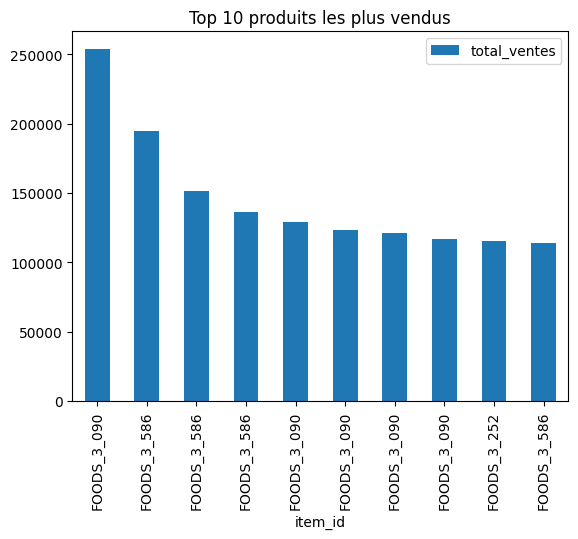

In [6]:
# Total ventes par produit
df['total_ventes'] = df[colonnes_ventes].sum(axis=1)
top10 = df[['item_id', 'total_ventes']].sort_values(by='total_ventes', ascending=False).head(10)
print("Top 10 produits les plus vendus : ")
print(top10)

top10.plot(kind='bar', x='item_id', y='total_ventes')
plt.title("Top 10 produits les plus vendus")
plt.show()

Les produits alimentaires (FOODS) dominent largement le top 10 avec des ventes très élevées (>100 000 unités).

Les produits des autres catégories (HOUSEHOLD et HOBBIES) n'apparaissent pas dans le top 10, ce qui suggère que la demande pour les produits alimentaires est beaucoup plus forte.

Certains produits comme FOODS_3_090 et FOODS_3_586 apparaissent plusieurs fois, ce qui montre qu'il y a des variantes ou lots différents très populaires dans la même sous-catégorie.

## Moyenne écart type par produit

             item_id  moyenne_journaliere  ecart_type
0      HOBBIES_1_001             0.326121    0.708041
1      HOBBIES_1_002             0.257599    0.568594
2      HOBBIES_1_003             0.159196    0.501446
3      HOBBIES_1_004             1.719217    1.986809
4      HOBBIES_1_005             0.972694    1.292634
...              ...                  ...         ...
30485    FOODS_3_823             0.535806    1.172881
30486    FOODS_3_824             0.375064    0.816377
30487    FOODS_3_825             0.893354    1.379699
30488    FOODS_3_826             0.380732    0.973790
30489    FOODS_3_827             0.702731    1.509673

[30490 rows x 3 columns]


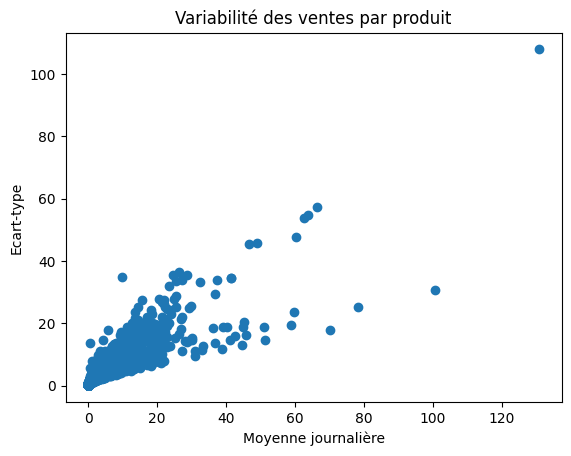

In [7]:
df['moyenne_journaliere'] = df[colonnes_ventes].mean(axis=1)
df['ecart_type'] = df[colonnes_ventes].std(axis=1)
print(df[['item_id', 'moyenne_journaliere', 'ecart_type']])

plt.scatter(df['moyenne_journaliere'], df['ecart_type'])
plt.xlabel("Moyenne journalière")
plt.ylabel("Ecart-type")
plt.title("Variabilité des ventes par produit")
plt.show()

Ces variables seront utiles pour analyser la saisonnalité des produits et faire des prévisions. 

Moyenne journalière nous donne le volume moyen vendu par jour pour chaque produit (peut servir pour anticiper le stock quotidien). Ecart-type nous permettra de mesurer la variabilité des ventes (un écart tupe élevé signifie que les ventes fluctuent beaucoup d'un jour à l'autre alors qu'un écart-type faible indique des ventes régulières.

## Histogramme des ventes totales

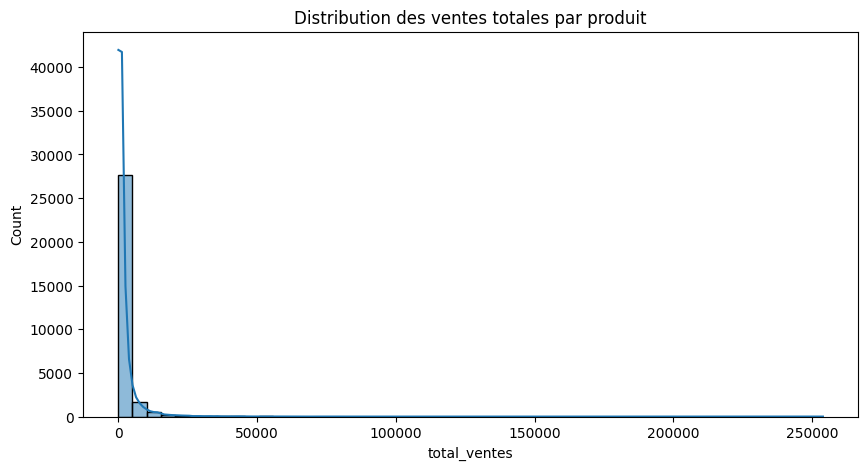

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['total_ventes'], bins=50, kde=True)
plt.title("Distribution des ventes totales par produit")
plt.show()

L'axe X représente le total des ventes par produits et l'axe Y est le nombre de prodits ayant ce total de ventes.

Le graphe montre que beaucoup de produits ont de très faibles ventes (pic à gauche) et peu de produits ont des ventes élevées (partie droite). Cela ne signifie pas que les ventes sont à 0, mais plutot que la majorité des produits ont un faible volume et quelques-uns font le gros des ventes.

## Boxplot par catégories

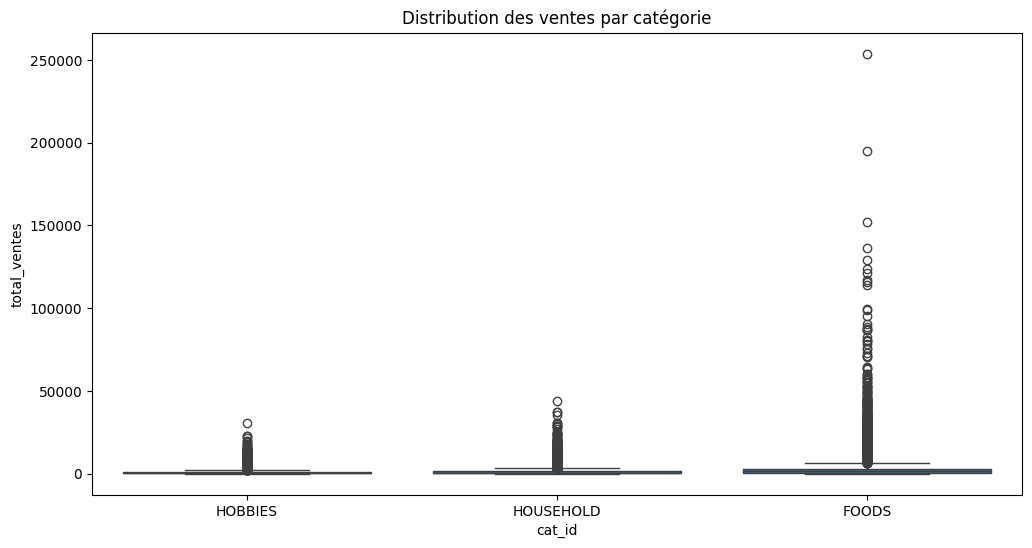

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(x='cat_id', y='total_ventes', data=df)
plt.title("Distribution des ventes par catégorie")
plt.show()

On observe clairement que la catégorie Food domine largement. Les ventes sont relativement régulière sauf lorsqu'on monte dans le pic. Household est légèrement plus grande que Hobbies mais elles restent toutes deux faibles face à Foods.